# Preprocessing pipeline

**Goal** here is to select a proper window of samples.

Apply **filtering** within the window to interpolate data during blinks

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.interpolate as cwi
from importlib import reload
reload(cwi)
reload(cwpre)
COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = [1]
EXPERIMENTS = [1,2,3,4]

In [176]:
# Load the dataset
eye_df = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print("Loaded eye-tracking data shape:", eye_df.shape)

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8754 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
Loaded eye-tracking data shape: (10312, 12)


In [177]:
# Checking the different cl values for subject id
display(eye_df[eye_df["subject_id"] == 21].groupby("task_id")["cl_class"].unique())

Series([], Name: cl_class, dtype: str)

## A. Extract window

Extract a proper window for analysis. Also validates invididual methods used for preprocessing.

*A priori* using $T\approx 10s$ consisting of $N=512$ samples seems like a good start.

Thus, inference could be done on a *per second* basis, giving overlapping windows of N~448 samples

In [178]:
N = 300 # Number of samples in the window
offset = 0 # Offset in # samples for the start of the window
fs = 60
SUBJECT_ID = 1
TASK_ID = 4

subject_df = eye_df[(eye_df["subject_id"] == SUBJECT_ID) & (eye_df["task_id"] == TASK_ID)].reset_index(drop=True)
print("Extracting a window of {} samples which corresponds to {:.2f} seconds".format(N, N/fs))
window_df = subject_df.iloc[offset:offset+N].copy()

window_df.head()

Extracting a window of 300 samples which corresponds to 5.00 seconds


,timestamp_sec,eye_id,pupil_diameter_px,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z,subject_id,task_id,cl_class
0,0.001745,0.0,39.079651,0.999910,0.429778,0.894138,-7.849854,-30.436482,68.829957,1,4,medium
1,0.018415,0.0,39.302570,0.999893,0.430029,0.894655,-7.868716,-30.663442,69.251569,1,4,medium
2,0.035085,0.0,39.364880,0.999730,0.433339,0.900598,-7.489608,-31.173530,69.349582,1,4,medium
3,0.051755,0.0,39.223366,0.999913,0.438002,0.906767,-6.931100,-31.652872,69.343757,1,4,medium
4,0.068425,0.0,38.637367,0.999565,0.436891,0.906813,-7.024238,-31.463238,68.907065,1,4,medium


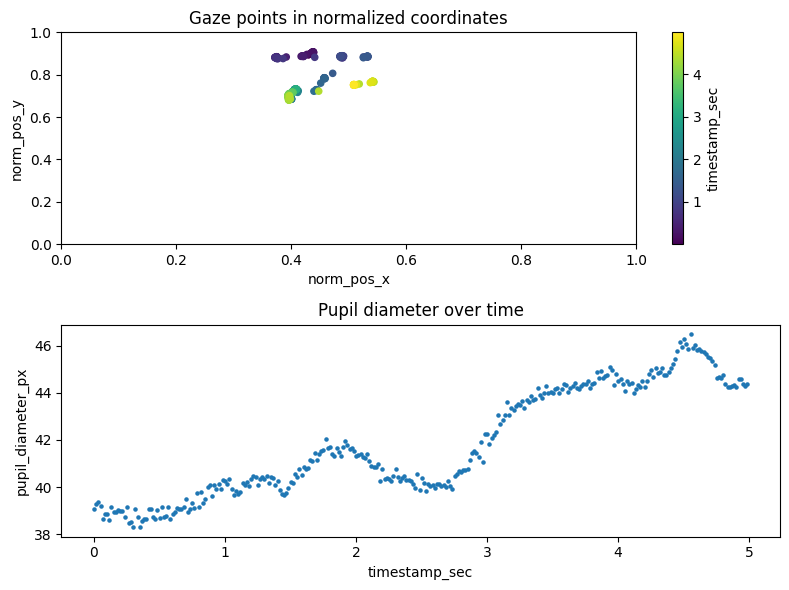

In [179]:
import matplotlib
# Visualize a bit the data in the window
fig = plt.figure(figsize=(8, 6), tight_layout=True)
ax0 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
# Plot gaze data in normalized coordinates
colormap = matplotlib.colormaps['viridis']
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
window_df.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp_sec', colormap=colormap, title="Gaze points in normalized coordinates", ax=ax0)

# Plot (best of the 2 eyes) pupil diameter over time 
# Inverse colormap mapping
window_df.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Pupil diameter over time", ax=ax2, sizes=[5])

# Overlay the blinks as vertical zones
# blink_df['blink_timestamp'] = blink_df['start_timestamp'] - window_df['timestamp_sec'].min() # Align blink timestamps with window timestamps
# blink_df_window = blink_df[(blink_df['blink_timestamp'] >= window_df['timestamp_sec'].min()) & (blink_df['blink_timestamp'] <= window_df['timestamp_sec'].max())]
# if blink_df_window.empty:
#     print("No (official) blinks detected in the current window.")
# for _, row in blink_df_window.iterrows():
#     ax2.axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)

# Show low confidence zones
window_df['low_confidence'] = window_df['confidence'] < 0.95
for _, row in window_df[window_df.low_confidence].iterrows():
    ax2.axvspan(row['timestamp_sec'], row['timestamp_sec'] + 1.0/240, color='orange', alpha=0.3)

Pipeline goes as follow:
1. Identify gaps and blinks
2. Remove low confidence samples
3. Apply margin to big gaps (> 75ms)
4. Filter pupil data
5. Calculate gaze angles
6. Interpolate gaps < 300ms by using resampling strategy (both pupil & gaze angle)

Detected gaps and blinks in the current window:


,start_id,stop_id,start_timestamp,stop_timestamp,duration_ms,is_blink


Removed 0 low confidence samples from the window.
Detected pupil diameter outliers in the current window:


,timestamp_sec,pupil_diameter_px,dilation_speed,is_outlier


Removed 0 pupil diameter outliers from the window.
Removed 0 samples due to low confidence and proximity to detected blinks/gaps.


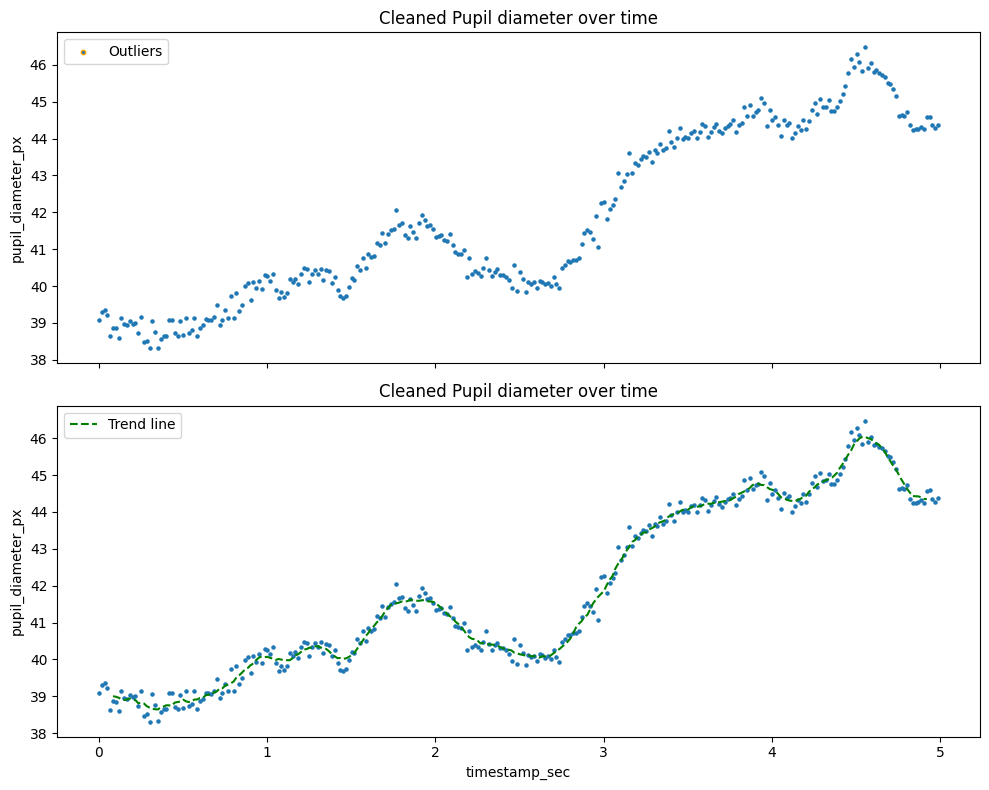

In [180]:
import cognitive_models.gaze_utils as cwgaze
import cognitive_models.pupil_utils as cwpupil
reload(cwgaze)
reload(cwpupil)

window_df_clean = window_df.copy()

CONFIDENCE_THRESHOLD = 0.95
MARGINS = 50 / 1000 # 50 ms margins around detected blinks and gaps
DURATION_THRESHOLD = 75
 
# Detect gaps and blinks in the current window
gaps_df = cwgaze.detect_gaps_and_blinks(window_df_clean, confidence_threshold=CONFIDENCE_THRESHOLD)
print("Detected gaps and blinks in the current window:")
display(gaps_df)

# Remove low confidence samples
n_to_remove = window_df_clean[window_df_clean["confidence"] < CONFIDENCE_THRESHOLD].shape[0]
window_df_clean = window_df_clean[window_df_clean["confidence"] >= CONFIDENCE_THRESHOLD]
print(f"Removed {n_to_remove} low confidence samples from the window.")

# Detect pupil diameter outliers
outliers_df = cwpupil.detect_outliers(window_df_clean, column="pupil_diameter_px", n_multiplier=10)
print("Detected pupil diameter outliers in the current window:")
display(outliers_df[["timestamp_sec", "pupil_diameter_px", "dilation_speed", "is_outlier"]])
window_df_clean = window_df_clean[~window_df_clean["timestamp_sec"].isin(outliers_df["timestamp_sec"])]
print(f"Removed {outliers_df.shape[0]} pupil diameter outliers from the window.")

# Remove samples that are within the margins of detected blinks and gaps
size_before = window_df_clean.shape[0]
for _, row in gaps_df[gaps_df['duration_ms'] >= DURATION_THRESHOLD].iterrows():
    idx_to_drop = window_df_clean[
        (window_df_clean['timestamp_sec'] >= row['start_timestamp'] - MARGINS) &
        (window_df_clean['timestamp_sec'] <= row['stop_timestamp'] + MARGINS)
    ].index
    window_df_clean.drop(idx_to_drop, inplace=True)

size_after = window_df_clean.shape[0]
print(f"Removed {size_before - size_after} samples due to low confidence and proximity to detected blinks/gaps.")

# Before interpolation, plot the pupil diameter with the detected gaps and blinks
fig, axs = plt.subplots(2, 1, figsize=(10, 8), tight_layout=True, sharex=True)
window_df_clean.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Cleaned Pupil diameter over time", ax=axs[0], sizes=[5])
for _, row in gaps_df.iterrows():
    axs[0].axvspan(row['start_timestamp'], row['stop_timestamp'], color='red', alpha=0.3)
outliers_df.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', ax=axs[0], sizes=[10], label="Outliers", edgecolors='orange')
axs[0].legend()

# Plot pupil diameter without outliers
window_df_clean.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Cleaned Pupil diameter over time", ax=axs[1], sizes=[5])
# Show a trend line to see the overall trend of the pupil diameter (using window convolution)
trend_line = np.convolve(window_df_clean["pupil_diameter_px"], np.ones(10)/10, mode='valid')
axs[1].plot(window_df_clean["timestamp_sec"][5:-4], trend_line[:len(window_df_clean)], color='green', label="Trend line", linestyle='--')
axs[1].legend()

After interpolation, we have 0 interpolated samples and 300 total samples.


<Axes: title={'center': 'Interpolated Gaze angle delta over time'}, xlabel='timestamp_sec', ylabel='gaze_angle_delta_deg'>

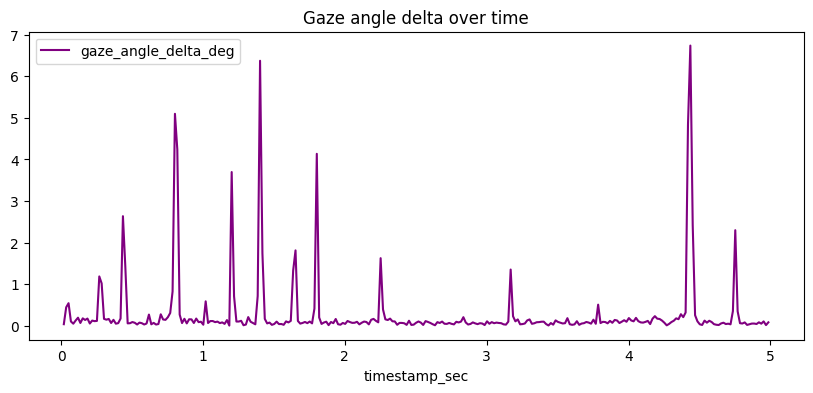

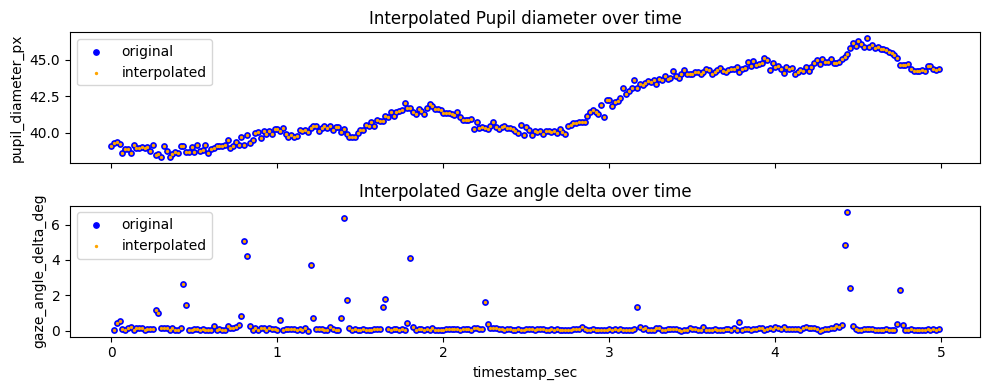

In [181]:
reload(cwi)
# Calculate gaze angles
window_df_clean['gaze_angle_delta_deg'] = cwgaze.calculate_gaze_angular_delta(window_df_clean)
window_df_clean.plot("timestamp_sec", "gaze_angle_delta_deg", kind='line', title="Gaze angle delta over time", color='purple', figsize=(10, 4))

# Only interpolate pupil diameter where gaps are smaller than a threshold
INTERPOLATION_THRESHOLD = 300 # ms
window_pupil_df_interpolated = cwi.interpolate_pupil_data(window_df_clean, gaps_df, column="pupil_diameter_px", max_gap=INTERPOLATION_THRESHOLD)
window_gaze_df_interpolated = cwi.interpolate_gaze_angle(window_df_clean, gaps_df, columns=["gaze_angle_delta_deg", "norm_pos_x", "norm_pos_y"], max_gap=INTERPOLATION_THRESHOLD)
print(f"After interpolation, we have {window_pupil_df_interpolated['is_interpolated'].sum()} interpolated samples and {window_pupil_df_interpolated.shape[0]} total samples.")

fig, axs = plt.subplots(2,1, figsize=(10, 4), tight_layout=True, sharex=True)
window_df_clean.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Cleaned Pupil diameter over time", color='blue', sizes=[15], ax=axs[0], label="original")
window_pupil_df_interpolated.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Interpolated Pupil diameter over time", color='orange', sizes=[2], ax=axs[0], label="interpolated")
axs[0].legend()
window_df_clean.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Cleaned Gaze angle delta over time", color='blue', sizes=[15], ax=axs[1], label="original")
window_gaze_df_interpolated.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Interpolated Gaze angle delta over time", color='orange', sizes=[2], ax=axs[1], label="interpolated")

Found 21 transitions between saccades and fixations
Will mark 0 short fixations as saccades


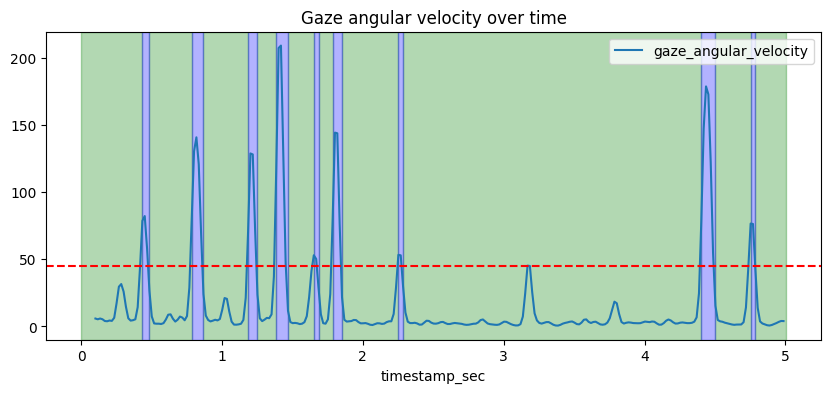

In [182]:
reload(cwgaze)
# Extract required features for the window
window_gaze_df_interpolated['gaze_angular_velocity'] = cwgaze.calculate_angular_velocity(window_gaze_df_interpolated)

window_df, fixations_df, saccades_df = cwgaze.calculate_fixations_saccades(window_gaze_df_interpolated, gaps_df, ivt_threshold=45)

# Plot fixations / saccades zones
fig, ax = plt.subplots(figsize=(10, 4))
window_df.plot("timestamp_sec", "gaze_angular_velocity", kind='line', title="Gaze angular velocity over time", ax=ax)
for _, row in fixations_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='green', alpha=0.3)
for _, row in saccades_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='blue', alpha=0.3)
ax.axhline(45, color='red', linestyle='--', label="IVT threshold")


In [183]:
# Using the preprocessing function
import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
reload(cwpupil)
reload(cwgaze)
reload(cwpre)
reload(cwfeat)

feature_rows = []
for t in range(N, len(subject_df), 300):
    window_df = subject_df.iloc[t-N:t].reset_index(drop=True)
    window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_colet_data(window_df, verbose=False)

    # Extract features
    features_dict = cwfeat.extract_window_features(
        window_preprocess_df, 
        window_gaze_df, 
        window_pupil_df, 
        window_gaps_df, 
        ivt_threshold=45, 
        min_fixation_duration=55, 
        verbose=False
    )

    feature_rows.append(features_dict)

features_df = pd.DataFrame(feature_rows)
print("Extracted features shape:", features_df.shape)
features_df.head(10)


Extracted features shape: (7, 19)


,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,saccades_amplitude_std,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,pupil_ripa2
0,10,428.419000,2100.42,83.35,597.234400,9,118.438194,1.061490,2.576900,0.097179,0.858946,44.453333,83.35,16.67,25.005000,0,0.00000,4.012575,0.004478
1,12,351.459167,1550.31,66.68,405.066240,11,94.883811,1.355512,2.407608,0.000000,0.923799,36.370909,50.01,16.67,16.364102,0,0.00000,4.213204,0.002651
2,6,775.155000,3450.69,150.03,1314.913285,5,82.535541,2.147500,4.925602,0.040900,1.823957,33.340000,50.01,16.67,16.670000,4,0.15003,4.012575,0.003473
3,9,487.134444,1250.25,116.69,365.200265,8,92.205482,0.539588,1.656769,0.056235,0.618387,41.675000,66.68,16.67,17.820980,0,0.00000,4.614462,0.004451
4,11,380.379091,916.85,100.02,291.302532,10,108.371767,1.301617,2.410584,0.047857,0.753669,46.676000,116.69,16.67,31.236178,0,0.00000,5.015719,0.002478
5,6,772.376667,2050.41,183.37,802.702765,6,84.168106,0.947784,2.030148,0.000000,0.881756,27.783333,66.68,0.00,25.097440,0,0.00000,4.815090,0.002712
6,11,390.987273,1616.99,100.02,460.850201,10,83.892645,1.008781,2.169925,0.021593,0.779064,35.007000,83.35,16.67,24.157125,0,0.00000,4.413833,0.002803
